# Credit Risk & Performance Analytics Dashboard
### Notebook 02 - Model Training & Evaluation

Training a few models to predict loan default, comparing them, and preparing the final scored dataset for the dashboard.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('../data/processed/loan_data_cleaned.csv')
print(df.shape)
df.head()

(32572, 21)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,cb_person_cred_hist_length,loan_to_income,early_career,high_int_rate,debt_burden,loan_to_cred_hist,emp_stability,age_group,income_group,cred_hist_group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,...,2,0.104167,0,1,0.017361,333.333333,Medium,<25,Low,Very Short
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,...,3,0.572917,1,1,0.286458,1375.000000,Unstable,<25,Low,Very Short
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,...,2,0.534351,0,1,0.106870,11666.666667,Medium,<25,Mid-High,Very Short
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,...,4,0.643382,0,1,0.071487,7000.000000,Stable,<25,Mid-Low,Short
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,...,2,0.252525,1,0,0.084175,833.333333,Low,<25,Low,Very Short


In [3]:
# columns I don't want to use directly
drop_cols = ['emp_stability', 'age_group', 'income_group', 'cred_hist_group']  # these are categorical groups I created earlier

df_model = df.drop(columns=drop_cols)

# encode remaining categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

Categorical columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income,early_career,high_int_rate,debt_burden,loan_to_cred_hist
0,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2,0.104167,0,1,0.017361,333.333333
1,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3,0.572917,1,1,0.286458,1375.000000
2,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2,0.534351,0,1,0.106870,11666.666667
3,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4,0.643382,0,1,0.071487,7000.000000
4,21,9900,2,2.0,5,0,2500,7.14,1,0.25,0,2,0.252525,1,0,0.084175,833.333333


In [4]:
X = df_model.drop('loan_status', axis=1)
y = df_model['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Default rate in train:", round(y_train.mean()*100, 2), "%")

Train shape: (26057, 16)
Test shape: (6515, 16)
Default rate in train: 21.82 %


### Model 1: Logistic Regression (Baseline)

In [5]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_log), 4))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      5093
           1       0.47      0.75      0.58      1422

    accuracy                           0.76      6515
   macro avg       0.69      0.76      0.70      6515
weighted avg       0.82      0.76      0.77      6515

ROC AUC: 0.8233


### Model 2: Random Forest

In [6]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10,
                                  class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      5093
           1       0.84      0.71      0.77      1422

    accuracy                           0.91      6515
   macro avg       0.88      0.84      0.86      6515
weighted avg       0.91      0.91      0.91      6515

ROC AUC: 0.9147


### Model 3: XGBoost

In [7]:
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                          scale_pos_weight=3, random_state=42, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))

XGBoost Results:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5093
           1       0.86      0.77      0.81      1422

    accuracy                           0.92      6515
   macro avg       0.90      0.87      0.88      6515
weighted avg       0.92      0.92      0.92      6515

ROC AUC: 0.9472


### Comparing Models

In [8]:
# putting all the numbers in one place so its easier to compare
results = []
for name, y_pred, y_prob in [('Logistic Regression', y_pred_log, y_prob_log),
                              ('Random Forest', y_pred_rf, y_prob_rf),
                              ('XGBoost', y_pred_xgb, y_prob_xgb)]:
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'ROC AUC': round(roc_auc_score(y_test, y_prob), 4)
    })

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC AUC
Logistic Regression    0.7578     0.4661  0.7532 0.5758   0.8233
      Random Forest    0.9087     0.8437  0.7138 0.7733   0.9147
            XGBoost    0.9213     0.8559  0.7686 0.8099   0.9472


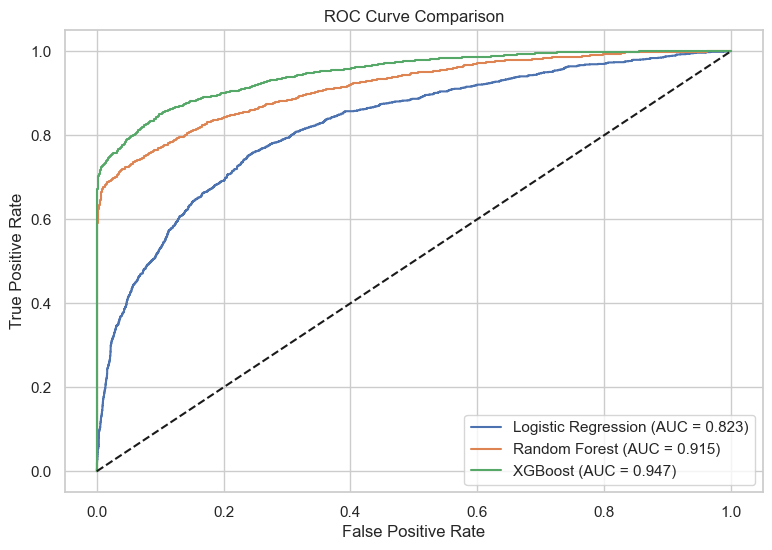

In [9]:
models = {
    'Logistic Regression': y_prob_log,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb
}

plt.figure(figsize=(9,6))
for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

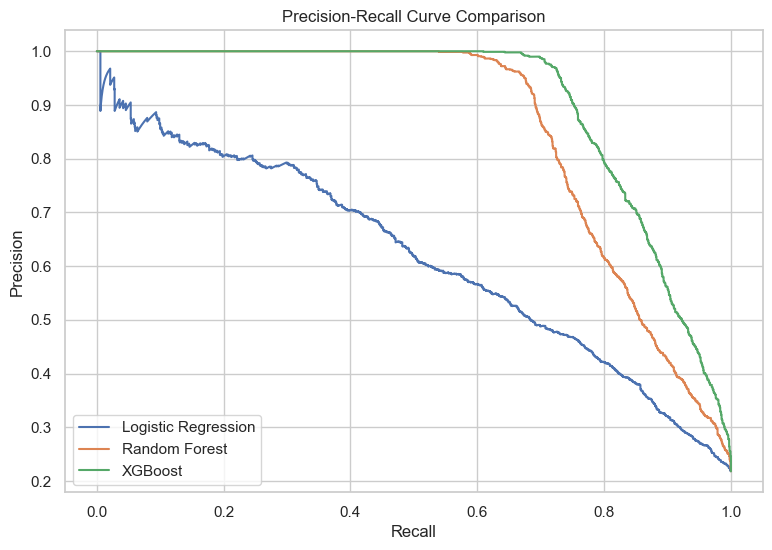

In [10]:
# precision-recall is honestly more useful for imbalanced data like this
plt.figure(figsize=(9,6))
for name, probs in models.items():
    prec, rec, _ = precision_recall_curve(y_test, probs)
    plt.plot(rec, prec, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()

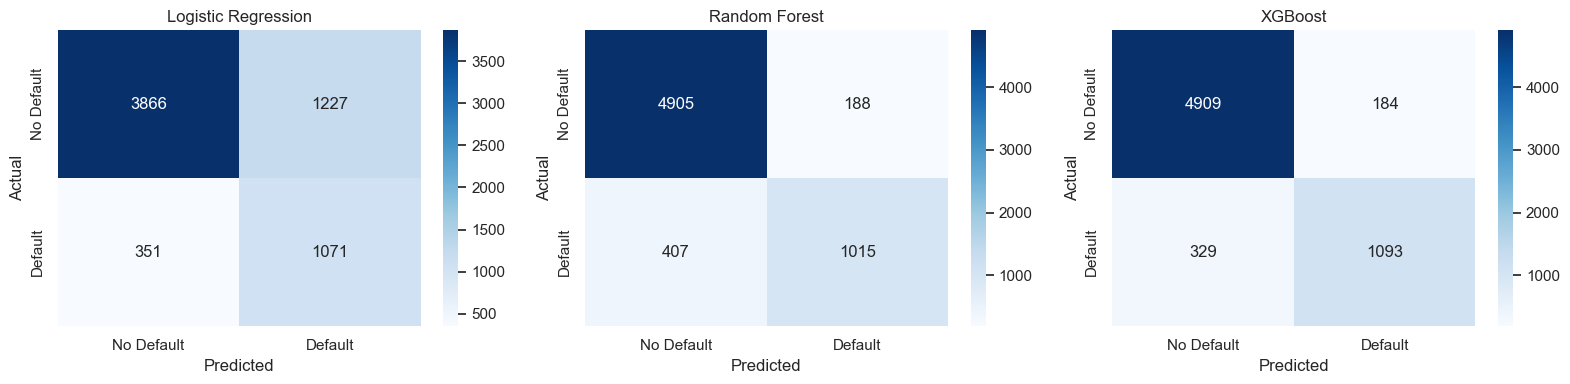

In [11]:
# confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_log),
                                      ('Random Forest', y_pred_rf),
                                      ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

### Feature Importance (XGBoost)

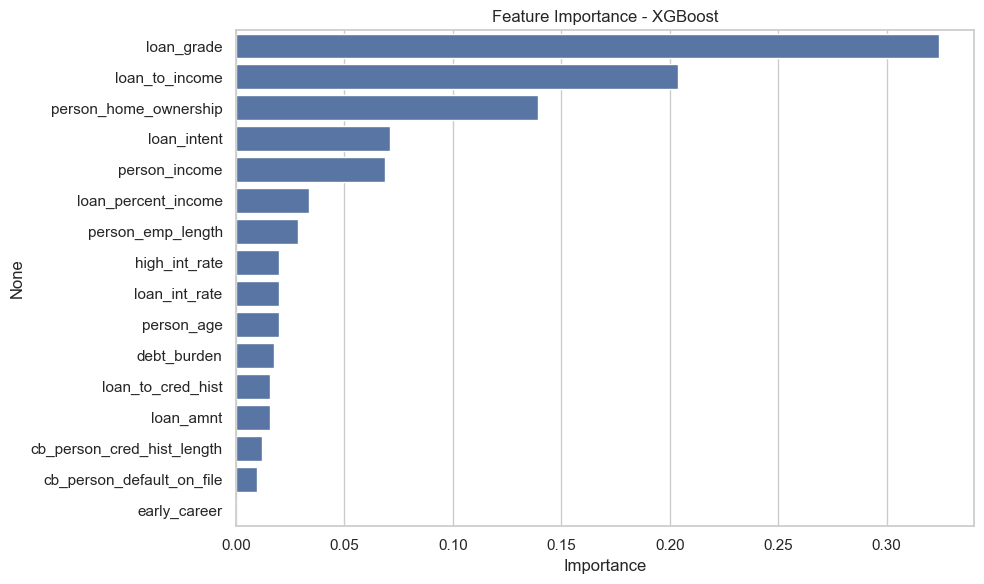

loan_grade               0.324081
loan_to_income           0.203659
person_home_ownership    0.139472
loan_intent              0.071017
person_income            0.068547
loan_percent_income      0.033920
person_emp_length        0.028611
high_int_rate            0.020037
loan_int_rate            0.019847
person_age               0.019722
dtype: float32


In [12]:
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(feat_imp.head(10))

### Final Model Selection & Saving Predictions

In [13]:
# Going with XGBoost as final model
final_model = xgb_model

# Predict on full data for dashboard
df_scored = df.copy()
df_scored['default_probability'] = final_model.predict_proba(X)[:, 1]
df_scored['predicted_default'] = final_model.predict(X)

# create risk segments
df_scored['risk_segment'] = pd.cut(df_scored['default_probability'],
                                   bins=[0, 0.3, 0.6, 1],
                                   labels=['Low Risk', 'Medium Risk', 'High Risk'])

print(df_scored['risk_segment'].value_counts())

risk_segment
Low Risk       23216
High Risk       5980
Medium Risk     3376
Name: count, dtype: int64


In [14]:
# save the scored dataset for Tableau
df_scored.to_csv('../data/processed/loan_data_scored.csv', index=False)
print("Scored dataset saved: data/processed/loan_data_scored.csv")

Scored dataset saved: data/processed/loan_data_scored.csv


In [15]:
print("Average default probability:", round(df_scored['default_probability'].mean(), 3))

print("\nDefault rate by Risk Segment:")
print(df_scored.groupby('risk_segment')['loan_status'].mean())

print("\nAverage loan amount by Risk Segment:")
print(df_scored.groupby('risk_segment')['loan_amnt'].mean().round(0))

Average default probability: 0.28

Default rate by Risk Segment:
risk_segment
Low Risk       0.016885
Medium Risk    0.278732
High Risk      0.965552
Name: loan_status, dtype: float64

Average loan amount by Risk Segment:
risk_segment
Low Risk        9315.0
Medium Risk     8508.0
High Risk      11258.0
Name: loan_amnt, dtype: float64


In [16]:
# digging a bit deeper - how do risk segments break down by grade and intent
print("Default rate by Loan Grade within Risk Segments:")
grade_risk = df_scored.groupby(['risk_segment', 'loan_grade'])['loan_status'].mean().unstack()
print(grade_risk.round(3))

print("\nDefault rate by Loan Intent within Risk Segments:")
intent_risk = df_scored.groupby(['risk_segment', 'loan_intent'])['loan_status'].mean().unstack()
print(intent_risk.round(3))

Default rate by Loan Grade within Risk Segments:
loan_grade        A      B      C      D      E      F    G
risk_segment                                               
Low Risk      0.013  0.020  0.022  0.013  0.011  0.000  NaN
Medium Risk   0.406  0.336  0.275  0.148  0.124  0.026  0.0
High Risk     0.995  0.989  0.950  0.949  0.960  0.971  1.0

Default rate by Loan Intent within Risk Segments:
loan_intent   DEBTCONSOLIDATION  EDUCATION  HOMEIMPROVEMENT  MEDICAL  \
risk_segment                                                           
Low Risk                  0.022      0.020            0.018    0.017   
Medium Risk               0.314      0.275            0.253    0.272   
High Risk                 0.991      0.962            0.960    0.956   

loan_intent   PERSONAL  VENTURE  
risk_segment                     
Low Risk         0.022    0.005  
Medium Risk      0.292    0.252  
High Risk        0.951    0.968  


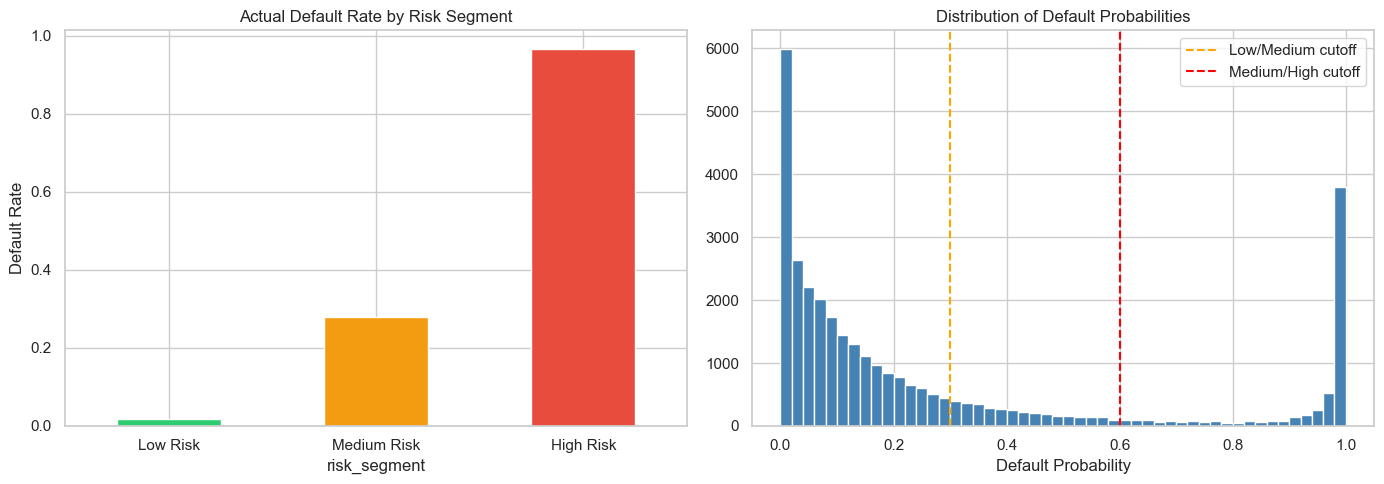


All done - scored dataset ready for the dashboard!


In [17]:
# quick visual to make sure the risk segments actually make sense
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_scored.groupby('risk_segment')['loan_status'].mean().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Actual Default Rate by Risk Segment')
axes[0].set_ylabel('Default Rate')
axes[0].tick_params(axis='x', rotation=0)

df_scored['default_probability'].hist(bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(0.3, color='orange', linestyle='--', label='Low/Medium cutoff')
axes[1].axvline(0.6, color='red', linestyle='--', label='Medium/High cutoff')
axes[1].set_title('Distribution of Default Probabilities')
axes[1].set_xlabel('Default Probability')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nAll done - scored dataset ready for the dashboard!")